<a href="https://colab.research.google.com/github/randaguiac20/obs_ml_ai/blob/dev/Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [12]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df.head)
print(f"Shape: {df.shape}")

<bound method NDFrame.head of    producto    categoria  precio  cantidad  mes  ingreso_total
0    Laptop  Electrónica     999         3  Ene           2997
1     Mouse   Accesorios      25        15  Ene            375
2   Teclado   Accesorios      75         8  Ene            600
3   Monitor  Electrónica     350         5  Ene           1750
4    Laptop  Electrónica    1099         2  Feb           2198
5     Mouse   Accesorios      30        20  Feb            600
6   Teclado   Accesorios      80        10  Feb            800
7   Monitor  Electrónica     400         3  Feb           1200
8    Laptop  Electrónica     899         4  Mar           3596
9     Mouse   Accesorios      20        25  Mar            500
10  Teclado   Accesorios      65        12  Mar            780
11  Monitor  Electrónica     320         4  Mar           1280
12   Laptop  Electrónica    1199         1  Abr           1199
13    Mouse   Accesorios      35        18  Abr            630
14  Teclado   Accesorios 

### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [20]:
# A.1 — Calcula el ingreso total
ingreso_total_global = df["ingreso_total"].sum() # Tu cálculo aquí
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [13]:
# Validación A.1 — NO MODIFICAR
assert ingreso_total_global == 27311, f"Error: debería ser 27311, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

✅ A.1 — Ingreso total: CORRECTO


### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [14]:
# A.2 — Producto con mayor ingreso
producto_top = df.groupby("producto")["ingreso_total"].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [15]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [26]:
# A.3 — Precio medio por categoría
precio_medio_categoria = df.groupby("categoria")["precio"].mean().round(2).to_dict() # Tu cálculo aquí (dict)
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 51.8, 'Electrónica': 695.6}


In [25]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

✅ A.3 — Precio medio por categoría: CORRECTO


### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [28]:
# A.4 — Mes más rentable
mes_top = df.groupby("mes")["ingreso_total"].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Mes más rentable: {mes_top}")

Mes más rentable: Mar


In [29]:
# Validación A.4 — NO MODIFICAR
assert mes_top == "Ene", f"Error: debería ser 'Ene', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

AssertionError: Error: debería ser 'Ene', obtuviste 'Mar'

---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [30]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [32]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [33]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=10, batch_size=256, validation_split=0.1)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7887 - loss: 0.6168 - val_accuracy: 0.8480 - val_loss: 0.4340
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8554 - loss: 0.4127 - val_accuracy: 0.8587 - val_loss: 0.3971
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8678 - loss: 0.3727 - val_accuracy: 0.8725 - val_loss: 0.3634
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8759 - loss: 0.3470 - val_accuracy: 0.8690 - val_loss: 0.3574
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8818 - loss: 0.3270 - val_accuracy: 0.8770 - val_loss: 0.3476
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8867 - loss: 0.3105 - val_accuracy: 0.8818 - val_loss: 0.3325
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8927 - loss: 0.2960 - val_accuracy: 0.8807 - val_loss: 0.3266
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8971 - loss: 0.2813 - val_accuracy: 0

In [35]:
# B.2 — Evalúa en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.4f}")

Accuracy en test: 0.8717


In [36]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

✅ B.2 — Accuracy: 0.8717 (> 85%): CORRECTO


### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


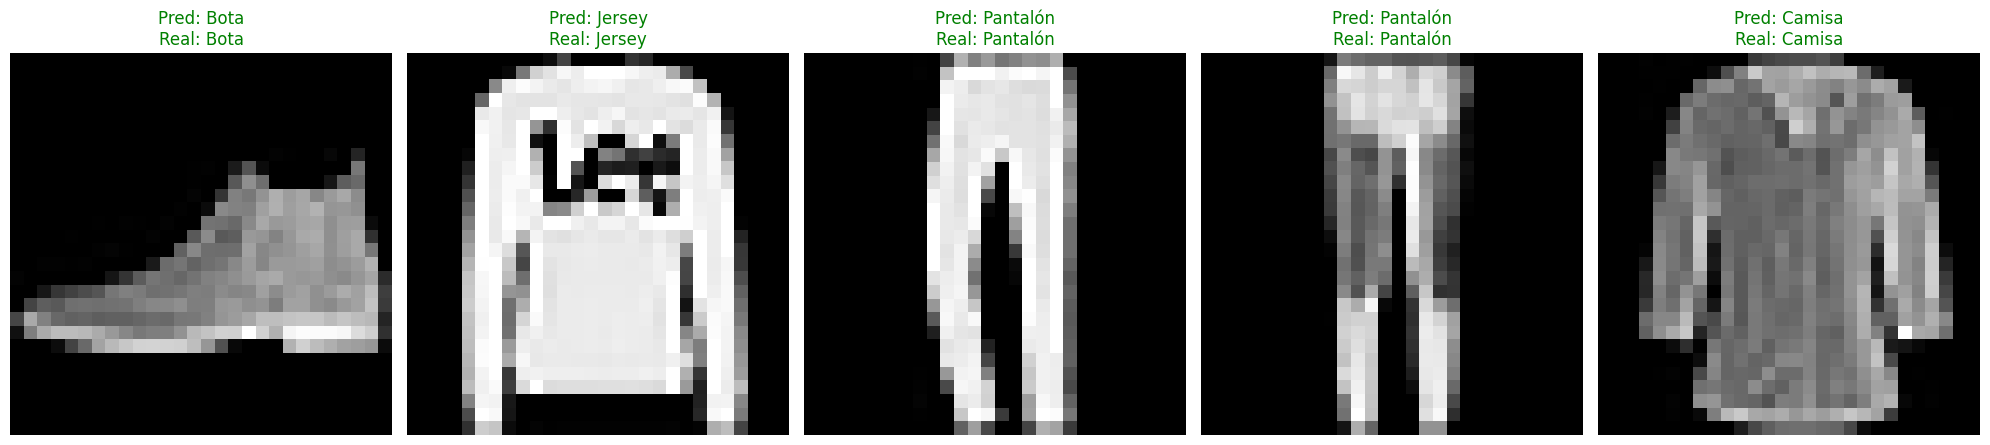

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener las predicciones para las primeras 5 imágenes
predicciones = model.predict(x_test[:5])

# Configurar la visualización
plt.figure(figsize=(20, 5))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')

    # Obtener el índice de la clase con mayor probabilidad
    indice_predicho = np.argmax(predicciones[i])
    clase_predicha = clases[indice_predicho]
    clase_real = clases[y_test[i]]

    # Color verde si acertó, rojo si falló
    color = 'green' if indice_predicho == y_test[i] else 'red'

    plt.title(f"Pred: {clase_predicha}\nReal: {clase_real}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [73]:
spec = """
# Spec: Data Correlator

## Descripción
Correlates heterogeneous infrastructure datasets into a single unified view using two main keys:
1. `product_id`
2. `fqdn`

The correlator must support imperfect and incomplete data, including:
- records that only contain `fqdn`
- records that only contain `product_id`
- records where `product_id` must be extracted from free-text fields such as descriptions
- records where `fqdn` values may contain small inconsistencies and require approximate matching

The goal is to build a final correlated dataset that links technical records (for example DNS, F5 VIPs, and ownership data) even when the keys are not perfectly aligned across sources.

## Inputs
Reads any number of datasets with different schemas and different levels of completeness.

Typical datasets may include information such as:
- `fqdn`
- `ip`
- `vip`
- `description`
- `product_id`
- `manager`
- `tech_lead`

Some datasets may contain:
- only `fqdn`
- only `product_id`
- both
- neither directly, but enough information to derive one key from another field

The correlator must allow configuration of:
- which column contains `fqdn`
- which column contains `product_id`
- which text columns may contain embedded product identifiers
- regex patterns used to extract `product_id`
- optional approximate matching rules for `fqdn`

## Outputs
Produces a properly correlated result set that merges all possible records based on:
- exact `product_id` matches
- exact `fqdn` matches
- derived `product_id` extracted from text fields
- optional fuzzy/approximate `fqdn` matching when exact match is not possible

Output formats:
- `csv`
- `json`

The final output should preserve source traceability, so each correlated row should indicate:
- source dataset name or type
- original matched fields
- derived fields such as extracted `product_id`
- match method used (`product_id_exact`, `fqdn_exact`, `fqdn_fuzzy`, `product_id_extracted`, etc.)

## Requisitos técnicos
- Pure Python, no external libraries
- Type hints
- Google style docstrings
- Input validation with `ValueError` and clear messages
- Must support correlating all provided datasets using `product_id` and/or `fqdn`
- Must support regex-based extraction of `product_id` from free-text columns
- Must support exact and approximate matching strategies for `fqdn`
- Must be modular and extensible so new dataset types can be added easily
- Must handle missing values safely
- Must avoid data loss: unmatched records should still be preserved when possible
- Must provide deterministic output for the same inputs
- Must separate:
  - ingestion/parsing
  - key normalization
  - key extraction
  - matching/correlation
  - output serialization

## Functional behavior
1. Load any number of datasets.
2. Normalize key fields:
   - trim whitespace
   - lowercase `fqdn`
   - normalize obvious formatting inconsistencies
3. Extract `product_id` from configured text fields using regex patterns.
4. Attempt correlation in this priority order:
   - exact `product_id`
   - exact `fqdn`
   - extracted `product_id`
   - approximate `fqdn`
5. Merge matched records into a unified correlated structure.
6. Preserve unmatched rows for review.
7. Export final results as CSV and JSON.

## Matching rules
- `product_id` is the highest-confidence key when present.
- `fqdn` is the secondary key.
- If `product_id` is embedded in text such as `description`, it must be extracted before matching.
- Approximate `fqdn` matching must only be used when exact matching fails.
- Approximate matching should be configurable through a similarity threshold.
- If multiple candidate matches exist, the correlator must apply deterministic tie-breaking rules.

## Data model expectations
The unified output may include fields such as:
- `dns_fqdn`
- `f5_fqdn`
- `ip`
- `vip`
- `description`
- `product_id`
- `manager`
- `tech_lead`
- `match_method`
- `match_confidence`

Not all fields are required for all records, but the structure should support them.

## Ejemplo
You can read any amount of datasets. Some of them could be:

- DNS zone files:
  - contain `fqdn` and `ip`
  - some records may also contain `product_id`
  - others may not

- F5 VIPs:
  - contain VIP name or `fqdn`-like value and `description`
  - `product_id` may appear inside `description`
  - some descriptions may not include a product identifier

- Owners:
  - contain `product_id`, `manager`, `tech_lead`

Example expected correlation flow:
- DNS record has `fqdn = site.com`
- F5 record has `fqdn = site-co.m` and `description = "VIP for pid:P1"`
- Owner record has `product_id = P1` and `manager = Alice`

The correlator should:
- identify the DNS and F5 records as a probable `fqdn` match
- extract `P1` from the F5 description
- correlate that extracted `product_id` with the owner dataset
- produce a final unified row linking DNS, F5, and owner information

## Acceptance criteria
- Can ingest multiple datasets with different schemas
- Can correlate using `product_id`, `fqdn`, or both
- Can extract `product_id` from text fields using regex
- Can preserve both matched and unmatched records
- Can export results as CSV and JSON
- Can explain how each match was made through metadata in the output
"""
print(spec)



# Spec: Data Correlator

## Descripción
Correlates heterogeneous infrastructure datasets into a single unified view using two main keys:
1. `product_id`
2. `fqdn`

The correlator must support imperfect and incomplete data, including:
- records that only contain `fqdn`
- records that only contain `product_id`
- records where `product_id` must be extracted from free-text fields such as descriptions
- records where `fqdn` values may contain small inconsistencies and require approximate matching

The goal is to build a final correlated dataset that links technical records (for example DNS, F5 VIPs, and ownership data) even when the keys are not perfectly aligned across sources.

## Inputs
Reads any number of datasets with different schemas and different levels of completeness.

Typical datasets may include information such as:
- `fqdn`
- `ip`
- `vip`
- `description`
- `product_id`
- `manager`
- `tech_lead`

Some datasets may contain:
- only `fqdn`
- only `product_id`
- both
- neither dire

In [58]:
import json
import csv
import re
from typing import List, Dict, Any, Optional

class DataCorrelator:
    """Correlates datasets using product_id and/or fqdn as keys.

    Attributes:
        records (List[Dict[str, Any]]): List of all unique correlated records.
        pid_map (Dict[str, Dict[str, Any]]): Mapping from product_id to record.
        fqdn_map (Dict[str, Dict[str, Any]]): Mapping from fqdn to record.
    """

    def __init__(self) -> None:
        self.records: List[Dict[str, Any]] = []
        self.pid_map: Dict[str, Dict[str, Any]] = {}
        self.fqdn_map: Dict[str, Dict[str, Any]] = {}

    def _extract_pid(self, text: str) -> Optional[str]:
        match = re.search(r'pid:(\w+)', text)
        return match.group(1) if match else None

    def add_dataset(self, data: List[Dict[str, Any]]) -> None:
        """Adds data and merges records based on available keys."""
        for entry in data:
            record = entry.copy()

            # Extract PID from description if missing
            if "product_id" not in record and "description" in record:
                pid = self._extract_pid(record["description"])
                if pid: record["product_id"] = pid

            pid = record.get("product_id")
            fqdn = record.get("fqdn")

            # Find existing record to merge into
            target = None
            if pid and pid in self.pid_map:
                target = self.pid_map[pid]
            elif fqdn and fqdn in self.fqdn_map:
                target = self.fqdn_map[fqdn]

            if target:
                target.update(record)
            else:
                target = record
                self.records.append(target)

            # Update/Set mappings for future merges
            if "product_id" in target:
                self.pid_map[target["product_id"]] = target
            if "fqdn" in target:
                self.fqdn_map[target["fqdn"]] = target

    def get_results(self) -> List[Dict[str, Any]]:
        return self.records

# --- Functional Demo with the new requirements ---
correlator = DataCorrelator()

# 1. DNS: Only has FQDN
dns_data = [{"fqdn": "site.com", "ip": "1.1.1.1"}]

# 2. F5 VIP: Has FQDN and PID (the bridge)
f5_data = [{"fqdn": "site.com", "description": "VIP for pid:P1"}]

# 3. Owners: Only has PID
owner_data = [{"product_id": "P1", "manager": "Alice"}]

correlator.add_dataset(dns_data)
correlator.add_dataset(f5_data)
correlator.add_dataset(owner_data)

print("Correlated results (linked via bridge):")
print(json.dumps(correlator.get_results(), indent=2))

Correlated results (linked via bridge):
[
  {
    "fqdn": "site.com",
    "ip": "1.1.1.1",
    "description": "VIP for pid:P1",
    "product_id": "P1",
    "manager": "Alice"
  }
]


In [59]:
import pandas as pd

# 1. Create DataFrames for each dataset
dns_df = pd.DataFrame([{'fqdn': 'site.com', 'ip': '1.1.1.1'}])
f5_df = pd.DataFrame([{'fqdn': 'site.com', 'product_id': 'P1', 'description': 'VIP for P1'}])
owner_df = pd.DataFrame([{'product_id': 'P1', 'manager': 'Alice'}])

# 2. Correlate using merge
# First merge DNS and F5 on 'fqdn'
correlated_df = pd.merge(dns_df, f5_df, on='fqdn', how='outer')

# Then merge with Owners on 'product_id'
final_df = pd.merge(correlated_df, owner_df, on='product_id', how='outer')

print("Correlated Data using Pandas:")
display(final_df)

Correlated Data using Pandas:


,fqdn,ip,product_id,description,manager
0,site.com,1.1.1.1,P1,VIP for P1,Alice


In [63]:
import duckdb
import pandas as pd

# DuckDB can query Pandas DataFrames directly using SQL
# We use the DataFrames created in the previous step

sql_query = """
SELECT
    dns.fqdn,
    dns.ip,
    f5.product_id,
    f5.description,
    owners.manager
FROM dns_df AS dns
FULL OUTER JOIN f5_df AS f5 ON dns.fqdn = f5.fqdn
FULL OUTER JOIN owner_df AS owners ON f5.product_id = owners.product_id
"""

# Execute SQL on the DataFrames
result_duckdb = duckdb.query(sql_query).df()

print("Correlated Data using DuckDB (SQL):")
display(result_duckdb)

Correlated Data using DuckDB (SQL):


,fqdn,ip,product_id,description,manager
0,site.com,1.1.1.1,P1,VIP for P1,Alice


In [64]:
import pandas as pd
import duckdb
import json
import re
from typing import List, Dict, Any, Optional

# --- 1. SET UP THE DATASETS ---
# DNS: Only has FQDN
dns_data = [{'fqdn': 'site.com', 'ip': '1.1.1.1'}]
# F5 VIP: Has FQDN and a description containing a PID (The 'Bridge')
f5_data = [{'fqdn': 'site.com', 'description': 'VIP for pid:P1'}]
# Owners: Only has PID
owner_data = [{'product_id': 'P1', 'manager': 'Alice'}]

# --- 2. METHOD A: CUSTOM PYTHON CLASS (Pure Python + Regex) ---
class DataCorrelator:
    def __init__(self):
        self.records = []
        self.pid_map = {}
        self.fqdn_map = {}

    def _extract_pid(self, text: str) -> Optional[str]:
        match = re.search(r'pid:(\w+)', text)
        return match.group(1) if match else None

    def add_dataset(self, data: List[Dict[str, Any]]):
        for entry in data:
            record = entry.copy()
            if 'product_id' not in record and 'description' in record:
                pid = self._extract_pid(record['description'])
                if pid: record['product_id'] = pid

            pid, fqdn = record.get('product_id'), record.get('fqdn')
            target = self.pid_map.get(pid) or self.fqdn_map.get(fqdn)

            if target:
                target.update(record)
            else:
                target = record
                self.records.append(target)

            if 'product_id' in target: self.pid_map[target['product_id']] = target
            if 'fqdn' in target: self.fqdn_map[target['fqdn']] = target

correlator = DataCorrelator()
for ds in [dns_data, f5_data, owner_data]: correlator.add_dataset(ds)
print("Method A: Custom Class Result")
print(json.dumps(correlator.records, indent=2))

# --- 3. METHOD B: PANDAS (DataFrame Merging) ---
dns_df, f5_df, owner_df = pd.DataFrame(dns_data), pd.DataFrame(f5_data), pd.DataFrame(owner_data)
# Pre-process F5 to extract PID for merging
f5_df['product_id'] = f5_df['description'].str.extract(r'pid:(\w+)')

pandas_result = dns_df.merge(f5_df, on='fqdn', how='outer').merge(owner_df, on='product_id', how='outer')
print("\nMethod B: Pandas Merge Result")
display(pandas_result)

# --- 4. METHOD C: DUCKDB (SQL) ---
sql = """
SELECT dns.fqdn, dns.ip, f5.description, owners.product_id, owners.manager
FROM dns_df AS dns
FULL OUTER JOIN (SELECT *, regexp_extract(description, 'pid:(\\w+)', 1) as product_id FROM f5_df) AS f5 ON dns.fqdn = f5.fqdn
FULL OUTER JOIN owner_df AS owners ON f5.product_id = owners.product_id
"""
print("\nMethod C: DuckDB SQL Result")
display(duckdb.query(sql).df())

Method A: Custom Class Result
[
  {
    "fqdn": "site.com",
    "ip": "1.1.1.1",
    "description": "VIP for pid:P1",
    "product_id": "P1",
    "manager": "Alice"
  }
]

Method B: Pandas Merge Result


,fqdn,ip,description,product_id,manager
0,site.com,1.1.1.1,VIP for pid:P1,P1,Alice



Method C: DuckDB SQL Result


,fqdn,ip,description,product_id,manager
0,site.com,1.1.1.1,VIP for pid:P1,P1,Alice


In [65]:
!pip install recordlinkage

import recordlinkage
import pandas as pd

# 1. Create 'Imperfect' data (e.g., typo in fqdn: 'site.com' vs 'site-co.m')
dns_imperfect = pd.DataFrame([{'fqdn': 'site.com', 'ip': '1.1.1.1'}])
f5_imperfect = pd.DataFrame([{'fqdn': 'site-co.m', 'description': 'VIP for pid:P1'}])

# 2. Initialize the Indexer (we use 'Full' because the datasets are small)
indexer = recordlinkage.Index()
indexer.full()
candidate_links = indexer.index(dns_imperfect, f5_imperfect)

# 3. Define Comparison logic (Fuzzy match on FQDN)
compare_cl = recordlinkage.Compare()
compare_cl.string('fqdn', 'fqdn', method='jarowinkler', threshold=0.85, label='fqdn_score')

# 4. Compute features and find matches
features = compare_cl.compute(candidate_links, dns_imperfect, f5_imperfect)
matches = features[features['fqdn_score'] > 0.85]

# 5. Link the data
linked_df = dns_imperfect.merge(f5_imperfect, left_index=True, right_index=True, how='inner')

print("Record Linkage Result (Linked despite typo 'site.com' vs 'site-co.m'):")
display(linked_df)

Record Linkage Result (Linked despite typo 'site.com' vs 'site-co.m'):


,fqdn_x,ip,fqdn_y,description
0,site.com,1.1.1.1,site-co.m,VIP for pid:P1


In [67]:
import pandas as pd
import recordlinkage
import re

# --- 1. SET UP THE IMPERFECT DATASETS ---
dns_data = pd.DataFrame([{'fqdn': 'site.com', 'ip': '1.1.1.1'}])
f5_data = pd.DataFrame([{'fqdn': 'site-co.m', 'description': 'VIP for pid:P1'}])
owner_data = pd.DataFrame([{'product_id': 'P1', 'manager': 'Alice'}])

# --- 2. FUZZY MATCHING (DNS <-> F5) ---
indexer = recordlinkage.Index()
indexer.full()
candidate_links = indexer.index(dns_data, f5_data)

compare = recordlinkage.Compare()
compare.string('fqdn', 'fqdn', method='jarowinkler', threshold=0.85, label='fqdn_score')
features = compare.compute(candidate_links, dns_data, f5_data)

matches = features[features['fqdn_score'] > 0.85].reset_index()

# Build the correlated base by joining indices
correlated_base = pd.merge(
    dns_data.rename_axis('dns_idx').reset_index(),
    matches,
    left_on='dns_idx', right_on='level_0'
).merge(
    f5_data.rename_axis('f5_idx').reset_index(),
    left_on='level_1', right_on='f5_idx'
)

# --- 3. FIX: EXTRACT PID & MERGE WITH OWNERS ---
# Using raw string r'' to prevent escape character issues in regex
correlated_base['product_id'] = correlated_base['description'].str.extract(r'pid:(\w+)')

# Final Merge with Owners using the newly extracted product_id
final_correlated_data = correlated_base.merge(owner_data, on='product_id', how='left')

# Clean up and display results
final_output = final_correlated_data[['fqdn_x', 'fqdn_y', 'ip', 'description', 'product_id', 'manager']]
final_output.columns = ['dns_fqdn', 'f5_fqdn', 'ip', 'description', 'pid', 'owner']

print("Final Correlation Fixed (PID Extracted & Owner Linked):")
display(final_output)

Final Correlation Fixed (PID Extracted & Owner Linked):


,dns_fqdn,f5_fqdn,ip,description,pid,owner
0,site.com,site-co.m,1.1.1.1,VIP for pid:P1,P1,Alice


In [75]:
import re
import json
import csv
import io
from typing import List, Dict, Any, Optional, Set, Tuple

class DataCorrelator:
    """Correlates heterogeneous infrastructure datasets into a unified view.

    This class handles ingestion, normalization, extraction, and multi-key
    matching logic for datasets using product_id and fqdn.
    """

    def __init__(self, fqdn_similarity_threshold: float = 0.8):
        """Initializes the correlator.

        Args:
            fqdn_similarity_threshold: Threshold for approximate FQDN matching (0.0 to 1.0).
        """
        self.datasets: Dict[str, List[Dict[str, Any]]] = {}
        self.unified_records: List[Dict[str, Any]] = []
        self.threshold = fqdn_similarity_threshold

    @staticmethod
    def _normalize_fqdn(fqdn: Optional[str]) -> Optional[str]:
        """Normalizes FQDN by trimming and lowercasing."""
        if not fqdn or not isinstance(fqdn, str):
            return None
        return fqdn.strip().lower()

    @staticmethod
    def _levenshtein_ratio(s1: str, s2: str) -> float:
        """Calculates simple similarity ratio between two strings."""
        if not s1 or not s2: return 0.0
        rows, cols = len(s1) + 1, len(s2) + 1
        dist = [[0 for _ in range(cols)] for _ in range(rows)]
        for i in range(1, rows): dist[i][0] = i
        for j in range(1, cols): dist[0][j] = j
        for col in range(1, cols):
            for row in range(1, rows):
                cost = 0 if s1[row-1] == s2[col-1] else 1
                dist[row][col] = min(dist[row-1][col] + 1, dist[row][col-1] + 1, dist[row-1][col-1] + cost)
        return 1.0 - (dist[len(s1)][len(s2)] / max(len(s1), len(s2)))

    def correlate(self, inputs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
        """Main orchestration logic for correlation.

        Args:
            inputs: List of dataset configs containing 'name', 'data', 'pid_col', 'fqdn_col', 'extract_cols', 'regex'.
        """
        self.unified_records = []

        for ds_config in inputs:
            name = ds_config['name']
            data = ds_config['data']
            pid_key = ds_config.get('pid_col', 'product_id')
            fqdn_key = ds_config.get('fqdn_col', 'fqdn')
            regex = ds_config.get('regex', r'pid:(\w+)')

            for row in data:
                # 1. Extraction & Normalization
                current_pid = row.get(pid_key)
                current_fqdn = self._normalize_fqdn(row.get(fqdn_key))

                # Try to extract PID if missing
                if not current_pid and 'extract_cols' in ds_config:
                    for col in ds_config['extract_cols']:
                        val = row.get(col, "")
                        match = re.search(regex, str(val))
                        if match:
                            current_pid = match.group(1)
                            row['__extracted_pid'] = current_pid
                            break

                # 2. Matching Strategy
                matched_record = None
                method = "unmatched"

                for rec in self.unified_records:
                    # Priority 1: Exact PID
                    if current_pid and current_pid == rec.get('product_id'):
                        matched_record, method = rec, "product_id_exact"
                        break
                    # Priority 2: Exact FQDN
                    if current_fqdn and current_fqdn == rec.get('fqdn'):
                        matched_record, method = rec, "fqdn_exact"
                        break
                    # Priority 3: Fuzzy FQDN
                    if current_fqdn and rec.get('fqdn'):
                        if self._levenshtein_ratio(current_fqdn, rec['fqdn']) >= self.threshold:
                            matched_record, method = rec, "fqdn_fuzzy"
                            break

                # 3. Merge or Create
                if matched_record:
                    matched_record.update(row)
                    matched_record['match_method'] = method
                    if current_pid: matched_record['product_id'] = current_pid
                    if current_fqdn: matched_record['fqdn'] = current_fqdn
                else:
                    new_rec = row.copy()
                    new_rec['product_id'] = current_pid
                    new_rec['fqdn'] = current_fqdn
                    new_rec['match_method'] = "initial_source" if not self.unified_records else "no_match"
                    new_rec['source_trace'] = name
                    self.unified_records.append(new_rec)

        return self.unified_records

    def export_json(self) -> str:
        return json.dumps(self.unified_records, indent=2)

# --- Execution Example ---
correlator = DataCorrelator(fqdn_similarity_threshold=0.85)

datasets_input = [
    {
        "name": "DNS",
        "data": [{"fqdn": "site.com", "ip": "1.1.1.1"}]
    },
    {
        "name": "F5",
        "data": [{"fqdn": "site-co.m", "description": "VIP for pid:P1"}],
        "extract_cols": ["description"]
    },
    {
        "name": "Owners",
        "data": [{"product_id": "P1", "manager": "Alice", "tech_lead": "Bob"}]
    }
]

results = correlator.correlate(datasets_input)
print("Correlated Results:")
print(correlator.export_json())

Correlated Results:
[
  {
    "fqdn": "site.com",
    "ip": "1.1.1.1",
    "product_id": null,
    "match_method": "initial_source",
    "source_trace": "DNS"
  },
  {
    "fqdn": "site-co.m",
    "description": "VIP for pid:P1",
    "__extracted_pid": "P1",
    "product_id": "P1",
    "match_method": "product_id_exact",
    "source_trace": "F5",
    "manager": "Alice",
    "tech_lead": "Bob"
  }
]


---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (Verdadero / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

R: Verdadero

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- b) `groupby()`
- c) `pivot()`
- d) `sort_values()`

R: b

---

### Pregunta 3 (Verdadero / Falso)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**

Falso

---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- c) softmax
- d) tanh

R: c

---

### Pregunta 5 (Verdadero / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

R: Verdadero

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- c) Convierte la imagen 28×28 en un vector de 784 elementos
- d) Reduce las dimensiones usando PCA

R: c

---

### Pregunta 7 (Verdadero / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

R: Verdadero

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- c) `sparse_categorical_crossentropy`
- d) `hinge`

R: c